
# 05 — Evaluation Metrics + Comparison Dashboard

This notebook evaluates both training runs:
- **Baseline:** random batching + LoRA
- **Proposed:** FAISS-grouped batching + LoRA

It produces:
1. training-dynamics metrics
2. generation-quality metrics (ROUGE-L, BERTScore)
3. retrieval/grouping metrics (coherence, diversity)
4. generalization-gap metrics
5. publishable tables and plots saved to Drive


In [ ]:

# --- 0) Mount Drive + install packages ---
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

!pip -q install -U evaluate bert-score rouge-score peft sentence-transformers datasets transformers accelerate pandas matplotlib faiss-cpu


Mounted at /content/drive
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 144.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 157.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 48.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of 

In [ ]:

# --- 1) Imports ---
import os
import json
import math
import random
from pathlib import Path
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import evaluate
import faiss

from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel


In [ ]:
# --- 2) Load bootstrap manifest + config ---
ROOT = '/content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research'
MANIFEST_PATH = f'{ROOT}/manifests/bootstrap_manifest.json'

if not os.path.exists(MANIFEST_PATH):
    raise FileNotFoundError(f'Manifest not found: {MANIFEST_PATH}')

with open(MANIFEST_PATH, 'r', encoding='utf-8') as f:
    manifest = json.load(f)

DIRS = manifest['dirs']

# ---------- Experiments to compare ----------
BASELINE_EXP_ID = 'exp_003_baseline_random_lora'
GROUPED_EXP_ID = 'exp_004_grouped_lora'
MIXED_EXP_ID = 'exp_006_grouped_mixed_lora'

RUN_SPECS = [
    {'exp_id': BASELINE_EXP_ID, 'run_name': 'baseline_random'},
    {'exp_id': GROUPED_EXP_ID, 'run_name': 'grouped_faiss'},
    {'exp_id': MIXED_EXP_ID, 'run_name': 'grouped_mixed'},
]

# ---------- Dataset / model ----------
DATASET_NAME = 'dolly_small_1k'
SPLIT_NAME = 'train'
INSTRUCTION_FIELD = 'instruction'
CONTEXT_FIELD = 'context'
RESPONSE_FIELD = 'response'
BASE_MODEL_DIRNAME = 'flan-t5-small'
BASE_MODEL_PATH = f"/content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_007_grouped_then_random_lora"

# ---------- Split policy (must match training notebooks) ----------
EVAL_RATIO = 0.1
SEED = 42

# ---------- Generation ----------
MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256
GEN_MAX_NEW_TOKENS = 96
GEN_NUM_BEAMS = 1
EVAL_MAX_SAMPLES = None   # e.g. 100 for quick run, None for full eval split

# ---------- Retrieval assets ----------
EMBED_MODEL_DIRNAME = 'all-MiniLM-L6-v2'
BUNDLE_NAME = f'{DATASET_NAME}__{EMBED_MODEL_DIRNAME}'
PER_DEVICE_BATCH = 8
N_RANDOM_BATCHES = 250
N_GROUPED_BATCHES = 250
N_MIXED_BATCHES = 250
MIXED_GROUPED_FRACTION = 0.80

# ---------- Output ----------
EVAL_EXP_ID = 'exp_005_eval_dashboard'
RUN_ROOT = f"{DIRS['experiments']}/{EVAL_EXP_ID}"
OUT_TABLES = f'{RUN_ROOT}/tables'
OUT_PLOTS = f'{RUN_ROOT}/plots'
OUT_LOGS = f'{RUN_ROOT}/logs'
for p in [RUN_ROOT, OUT_TABLES, OUT_PLOTS, OUT_LOGS]:
    os.makedirs(p, exist_ok=True)

# ---------- Recompute / cleanup ----------
RECOMPUTE_ALL = True
DELETE_OLD_EVAL_ARTIFACTS = True
REBUILD_EXPERIMENT_LOG_CSV = True

EXPERIMENT_LOG_CSV_PATH = f"{DIRS['experiments']}/experiment_logs/experiment_logs.csv"
os.makedirs(os.path.dirname(EXPERIMENT_LOG_CSV_PATH), exist_ok=True)

print('BASE_MODEL_PATH:', BASE_MODEL_PATH)
print('RUN_ROOT:', RUN_ROOT)
print('EXPERIMENT_LOG_CSV_PATH:', EXPERIMENT_LOG_CSV_PATH)

BASE_MODEL_PATH: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/shared/models/base_models/flan-t5-small
RUN_ROOT: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard
EXPERIMENT_LOG_CSV_PATH: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/experiment_logs/experiment_logs.csv


In [ ]:
# --- 3) Helpers ---
def _safe_read_json(path: str) -> Dict[str, Any]:
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def _read_jsonl(path: str) -> pd.DataFrame:
    if not path or not os.path.exists(path):
        print(f"[WARN] JSONL file not found: {path}")
        return pd.DataFrame()

    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def _path_with_experiments_fallback(path: str) -> str:
    if path and os.path.exists(path):
        return path

    if path and '/runs/' in path:
        alt = path.replace('/runs/', '/experiments/')
        if os.path.exists(alt):
            return alt

    return path


def _get_run_paths(exp_id: str) -> Dict[str, Any]:
    run_root = f"{DIRS['experiments']}/{exp_id}"
    summary_path = f'{run_root}/run_summary.json'

    if not os.path.exists(summary_path):
        raise FileNotFoundError(f'Run summary not found for {exp_id}: {summary_path}')

    summary = _safe_read_json(summary_path)

    # Prefer canonical paths from current folder structure
    canonical_adapter_path = f"{run_root}/adapter"
    canonical_metrics_jsonl = f"{run_root}/logs/metrics.jsonl"
    canonical_loss_plot = f"{run_root}/plots/loss_curve.png"

    # Fallback to summary paths if canonical ones do not exist
    adapter_path = canonical_adapter_path if os.path.exists(canonical_adapter_path) else _path_with_experiments_fallback(
        summary.get('paths', {}).get('adapter')
    )
    metrics_jsonl = canonical_metrics_jsonl if os.path.exists(canonical_metrics_jsonl) else _path_with_experiments_fallback(
        summary.get('paths', {}).get('metrics_jsonl')
    )
    loss_plot = canonical_loss_plot if os.path.exists(canonical_loss_plot) else _path_with_experiments_fallback(
        summary.get('paths', {}).get('loss_plot')
    )

    return {
        'run_root': run_root,
        'summary_path': summary_path,
        'summary': summary,
        'adapter_path': adapter_path,
        'metrics_jsonl': metrics_jsonl,
        'loss_plot': loss_plot,
    }


def build_prompt(example: Dict[str, Any]) -> str:
    instr = (example.get(INSTRUCTION_FIELD) or '').strip()
    ctx = (example.get(CONTEXT_FIELD) or '').strip()

    if ctx:
        return f"### Instruction:\n{instr}\n\n### Context:\n{ctx}\n\n### Response:\n"
    else:
        return f"### Instruction:\n{instr}\n\n### Response:\n"

def normalize_text(s: str) -> str:
    return ' '.join(str(s).strip().split())


def get_loss_frame(metrics_df: pd.DataFrame) -> pd.DataFrame:
    if 'loss' not in metrics_df.columns:
        return pd.DataFrame(columns=['step', 'loss'])
    out = metrics_df[metrics_df['loss'].notna()][['step', 'loss']].copy()
    out = out.sort_values('step').drop_duplicates(subset=['step'])
    return out.reset_index(drop=True)


def compute_training_dynamics(loss_df: pd.DataFrame, eval_loss: float, train_loss_last: float) -> Dict[str, Any]:
    if loss_df.empty:
        return {
            'initial_train_loss': None,
            'final_train_loss': train_loss_last,
            'best_train_loss': None,
            'eval_loss': eval_loss,
            'generalization_gap': (eval_loss - train_loss_last) if train_loss_last is not None and eval_loss is not None else None,
            'loss_variance': None,
            'loss_std': None,
            'convergence_step_90pct': None,
            'num_logged_points': 0,
        }

    losses = loss_df['loss'].astype(float).to_numpy()
    steps = loss_df['step'].astype(int).to_numpy()

    initial_loss = float(losses[0])
    best_loss = float(np.min(losses))
    final_loss_observed = float(losses[-1])
    target_loss = best_loss + 0.10 * (initial_loss - best_loss)

    hit_idx = np.where(losses <= target_loss)[0]
    convergence_step = int(steps[hit_idx[0]]) if len(hit_idx) > 0 else None

    return {
        'initial_train_loss': initial_loss,
        'final_train_loss': float(train_loss_last) if train_loss_last is not None else final_loss_observed,
        'best_train_loss': best_loss,
        'eval_loss': float(eval_loss) if eval_loss is not None else None,
        'generalization_gap': (float(eval_loss) - float(train_loss_last)) if train_loss_last is not None and eval_loss is not None else None,
        'loss_variance': float(np.var(losses)),
        'loss_std': float(np.std(losses)),
        'convergence_step_90pct': convergence_step,
        'num_logged_points': int(len(loss_df)),
    }


In [ ]:
# --- 3A) Cleanup helpers ---
def _safe_remove_file(path: str):
    if os.path.isfile(path):
        os.remove(path)

def _clear_directory_files(dir_path: str):
    if not os.path.exists(dir_path):
        return
    for name in os.listdir(dir_path):
        p = os.path.join(dir_path, name)
        if os.path.isfile(p):
            os.remove(p)

def _maybe_clear_eval_outputs():
    if not DELETE_OLD_EVAL_ARTIFACTS:
        return
    _clear_directory_files(OUT_TABLES)
    _clear_directory_files(OUT_PLOTS)
    _clear_directory_files(OUT_LOGS)
    print('Cleared old eval artifacts from:', RUN_ROOT)

if RECOMPUTE_ALL:
    _maybe_clear_eval_outputs()

Cleared old eval artifacts from: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard


In [ ]:
# --- 4) Load experiment runs ---
runs = {}
run_dynamics_rows = []

for spec in RUN_SPECS:
    exp_id = spec['exp_id']
    run_name = spec['run_name']

    run_obj = _get_run_paths(exp_id)
    summary = run_obj['summary']
    metrics_df = _read_jsonl(run_obj['metrics_jsonl'])
    loss_df = get_loss_frame(metrics_df)

    train_loss_last = summary.get('final_train_loss_last')
    if train_loss_last is None and not loss_df.empty:
        train_loss_last = float(loss_df.iloc[-1]['loss'])

    eval_loss = summary.get('final_eval_metrics', {}).get('eval_loss')

    dyn = compute_training_dynamics(loss_df, eval_loss, train_loss_last)

    runs[run_name] = {
        'exp_id': exp_id,
        'run_name': run_name,
        'obj': run_obj,
        'summary': summary,
        'metrics_df': metrics_df,
        'loss_df': loss_df,
        'train_loss_last': train_loss_last,
        'eval_loss': eval_loss,
        'dyn': dyn,
    }

    run_dynamics_rows.append({'run': run_name, **dyn})

pd.DataFrame(run_dynamics_rows)

,run,initial_train_loss,final_train_loss,best_train_loss,eval_loss,generalization_gap,loss_variance,loss_std,convergence_step_90pct,num_logged_points
0,baseline_random,9.712653,8.805094,8.783662,8.55408,-0.251014,0.057110,0.238976,1160,112
1,grouped_faiss,9.648692,8.827762,8.775226,8.55931,-0.268452,0.056778,0.238280,1300,99
2,grouped_mixed,9.667634,8.784276,8.745342,NaN,NaN,0.057931,0.240689,1280,112


In [ ]:

# --- 5) Rebuild the exact train/eval split used in training ---
dataset_path = f"{DIRS['shared_datasets_raw']}/{DATASET_NAME}"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f'Dataset not found: {dataset_path}')

ds = load_from_disk(dataset_path)
raw = ds[SPLIT_NAME]
raw = raw.map(lambda ex, idx: {'raw_idx': int(idx)}, with_indices=True)

base = raw.shuffle(seed=SEED)
n = len(base)
n_eval = max(1, int(n * EVAL_RATIO))
eval_ds = base.select(range(n_eval))
train_ds = base.select(range(n_eval, n))


def keep_example(ex):
    r = ex.get(RESPONSE_FIELD)
    i = ex.get(INSTRUCTION_FIELD)
    return (r is not None and str(r).strip() != '') and (i is not None and str(i).strip() != '')

train_ds = train_ds.filter(keep_example)
eval_ds = eval_ds.filter(keep_example)

if EVAL_MAX_SAMPLES is not None:
    eval_ds = eval_ds.select(range(min(EVAL_MAX_SAMPLES, len(eval_ds))))

print('Train size:', len(train_ds))
print('Eval size:', len(eval_ds))
print('Sample prompt preview:')
print(build_prompt(eval_ds[0]))
print('Target preview:', eval_ds[0][RESPONSE_FIELD][:250])


Train size: 900
Eval size: 100
Sample prompt preview:
### Instruction:
According to the following passage, what was the cause of the Great Chicago Fire?

### Context:
The fire is claimed to have started at about 8:30 p.m. on October 8, in or around a small barn belonging to the O'Leary family that bordered the alley behind 137 W. DeKoven Street. The shed next to the barn was the first building to be consumed by the fire. City officials never determined the cause of the blaze, but the rapid spread of the fire due to a long drought in that year's summer, strong winds from the southwest, and the rapid destruction of the water pumping system, explain the extensive damage of the mainly wooden city structures. There has been much speculation over the years on a single start to the fire. The most popular tale blames Mrs. O'Leary's cow, who allegedly knocked over a lantern; others state that a group of men were gambling inside the barn and knocked over a lantern. Still other speculation sugges

In [ ]:

# --- 6) Generation helpers + task-quality metrics ---
rouge = evaluate.load('rouge')
bertscore = evaluate.load('bertscore')


def load_model_with_adapter(adapter_path: str):
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
    base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL_PATH)
    model = PeftModel.from_pretrained(base_model, adapter_path)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    model.eval()
    return tokenizer, model, device


def batched_generate(adapter_path: str, ds_eval) -> List[str]:
    tokenizer, model, device = load_model_with_adapter(adapter_path)
    outputs = []

    bs = 8 if device == 'cuda' else 2
    for start in range(0, len(ds_eval), bs):
        batch = ds_eval.select(range(start, min(start + bs, len(ds_eval))))
        prompts = [build_prompt(ex) for ex in batch]

        enc = tokenizer(
            prompts,
            max_length=MAX_SOURCE_LEN,
            truncation=True,
            padding=True,
            return_tensors='pt',
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            gen_ids = model.generate(
                **enc,
                max_new_tokens=GEN_MAX_NEW_TOKENS,
                num_beams=GEN_NUM_BEAMS,
                do_sample=False,
            )

        texts = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
        outputs.extend([normalize_text(t) for t in texts])

    return outputs


def evaluate_predictions(name: str, predictions: List[str], references: List[str]) -> Dict[str, Any]:
    rouge_res = rouge.compute(predictions=predictions, references=references, use_stemmer=True)
    bert_res = bertscore.compute(predictions=predictions, references=references, lang='en')

    return {
        'run': name,
        'n_eval': len(references),
        'rouge1': float(rouge_res['rouge1']),
        'rouge2': float(rouge_res['rouge2']),
        'rougeL': float(rouge_res['rougeL']),
        'rougeLsum': float(rouge_res['rougeLsum']),
        'bertscore_precision': float(np.mean(bert_res['precision'])),
        'bertscore_recall': float(np.mean(bert_res['recall'])),
        'bertscore_f1': float(np.mean(bert_res['f1'])),
    }


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# --- 7) Run generation evaluation ---
references = [normalize_text(ex[RESPONSE_FIELD]) for ex in eval_ds]

predictions_by_run = {}
quality_rows = []

for run_name, run_info in runs.items():
    preds = batched_generate(run_info['obj']['adapter_path'], eval_ds)
    predictions_by_run[run_name] = preds
    quality_rows.append(evaluate_predictions(run_name, preds, references))

quality_df = pd.DataFrame(quality_rows)
quality_csv_path = f'{OUT_TABLES}/generation_quality_metrics.csv'
quality_df.to_csv(quality_csv_path, index=False)
quality_df

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


,run,n_eval,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1
0,baseline_random,100,0.088220,0.022907,0.077914,0.077767,0.746304,0.800936,0.771357
1,grouped_faiss,100,0.136960,0.048145,0.117088,0.117009,0.786511,0.815078,0.798354
2,grouped_mixed,100,0.112071,0.031663,0.098582,0.098811,0.752349,0.806928,0.777339


In [ ]:
# --- 8) Save qualitative examples for thesis appendix / supervisor review ---
examples_rows = []
for i, ex in enumerate(eval_ds):
    row = {
        'sample_id': i,
        'instruction': ex[INSTRUCTION_FIELD],
        'context': ex.get(CONTEXT_FIELD, ''),
        'reference': references[i],
    }
    for run_name in runs.keys():
        row[f'{run_name}_prediction'] = predictions_by_run[run_name][i]
    examples_rows.append(row)

examples_df = pd.DataFrame(examples_rows)
examples_path = f'{OUT_TABLES}/qualitative_eval_examples.csv'
examples_df.to_csv(examples_path, index=False)
examples_df.head(10)

,sample_id,instruction,context,reference,baseline_random_prediction,grouped_faiss_prediction,grouped_mixed_prediction
0,0,"According to the following passage, what was t...",The fire is claimed to have started at about 8...,There has been much speculation to the cause o...,the blaze is the first building to be consumed...,the fire is the first building to be consumed ...,"a long drought in that year's summer, strong w..."
1,1,Classify each of the following as either a hom...,,"The record player, subwoofer, and speaker are ...",the a home audio device a a home audio device ...,a home audio device a home audio device a piec...,a home audio device a home audio device a a pi...
2,2,Is plastic bad for us?,,Have you ever thought about where your plastic...,the plastic is a s and a s and a s and a s and...,plastic is a good for the s and s and a s and ...,plastic is a swath a swath a swath a swath a s...
3,3,I am registering for gifts for my wedding and ...,,"A blender, coffee maker, towels, sheets, dishe...","the tuxedo, the tuxedo, the tuxedo, the tuxedo...","a car, a car, a car, a car, a car, a car, a ca...","the tuxedo, the tuxedo, the tuxedo, the tuxedo..."
4,4,What should I do this spring in San Francisco?,,"During the spring time, people in San Francisc...",the a lot of the a lot of the a a lot of the a...,the s and the s and the s and the s and the s ...,the s and the s and the s and the s and the s ...
5,5,Who was the costliest player in Indian Premier...,,Pat Cummins (Australian Cricketer),the a ball is the a ball is the a ball is the ...,the a player in the Indian Premier League ( IP...,the a player in the Indian Premier League ( IP...
6,6,What are the four major tournaments for the Pr...,,The four major tournaments for the Professiona...,the a a a a a a a a a a a a a a a a a a a a a ...,the professional golfers association is the a ...,the a s and a s and a s and a s and a s and a ...
7,7,"How do I get to Juneau, Alaska?",,There are no roads that lead directly to Junea...,the a lot of the a lot of the a lot of the a l...,"Juneau, Alaska.","Juneau, Alaska is a s and a s and a s and a s ..."
8,8,What are the best superhero movies of 2022 ?,,The number of superhero movies produced year a...,the best superhero movies of 2022 .,the best superhero movies of 2022 .,the best superhero movies of 2022 .
9,9,Which country has the most inhabitants?,,# Country (or dependency) Population (2020) 1 ...,the country has the most people.,the country has the most people.,the country has the most people.


In [ ]:
# --- 9) Retrieval/grouping metrics: coherence + diversity ---
bundle_dir = f"{DIRS['shared_indexes_faiss']}/{BUNDLE_NAME}"
emb_path = f'{bundle_dir}/embeddings.npy'
neighbors_idx_path = f'{bundle_dir}/neighbors_topk_idx.npy'
neighbors_score_path = f'{bundle_dir}/neighbors_topk_scores.npy'

if not os.path.exists(emb_path):
    raise FileNotFoundError(f'Embeddings not found: {emb_path}')

X = np.load(emb_path).astype('float32')
neighbors_idx = np.load(neighbors_idx_path)
neighbors_score = np.load(neighbors_score_path)

# normalize for cosine computations
Xn = X / np.clip(np.linalg.norm(X, axis=1, keepdims=True), 1e-12, None)
train_raw_idxs = [int(x['raw_idx']) for x in train_ds]
raw_to_trainpos = {r: i for i, r in enumerate(train_raw_idxs)}
trainpos_to_raw = train_raw_idxs

def mean_anchor_member_cos(batch_raw_idxs: List[int]) -> float:
    a = batch_raw_idxs[0]
    sims = [float(np.dot(Xn[a], Xn[b])) for b in batch_raw_idxs]
    return float(np.mean(sims))

def mean_pairwise_cos(batch_raw_idxs: List[int]) -> float:
    vals = []
    for i in range(len(batch_raw_idxs)):
        for j in range(i + 1, len(batch_raw_idxs)):
            vals.append(float(np.dot(Xn[batch_raw_idxs[i]], Xn[batch_raw_idxs[j]])))
    return float(np.mean(vals)) if vals else 1.0

def batch_diversity(batch_raw_idxs: List[int]) -> float:
    return float(1.0 - mean_pairwise_cos(batch_raw_idxs))

def simulate_random_batches(train_raw_idxs: List[int], batch_size: int, seed: int, n_batches: int) -> List[List[int]]:
    rng = random.Random(seed)
    idxs = train_raw_idxs.copy()
    rng.shuffle(idxs)
    batches = []
    for i in range(0, len(idxs), batch_size):
        b = idxs[i:i+batch_size]
        if len(b) == batch_size:
            batches.append(b)
        if len(batches) >= n_batches:
            break
    return batches

class GroupedTrainBatchSampler:
    def __init__(self, trainpos_to_raw, raw_to_trainpos, neighbors_idx, seed, batch_size, drop_last=True):
        self.trainpos_to_raw = trainpos_to_raw
        self.raw_to_trainpos = raw_to_trainpos
        self.neighbors_idx = neighbors_idx
        self.seed = seed
        self.batch_size = batch_size
        self.drop_last = drop_last
        self.n = len(trainpos_to_raw)

    def __iter__(self):
        rng = random.Random(self.seed)
        anchors = list(range(self.n))
        rng.shuffle(anchors)
        used_global = set()

        for a_pos in anchors:
            if a_pos in used_global:
                continue

            a_raw = self.trainpos_to_raw[a_pos]
            batch = [a_pos]
            used_in_batch = {a_pos}

            for nb_raw in self.neighbors_idx[a_raw]:
                if len(batch) >= self.batch_size:
                    break
                nb_raw = int(nb_raw)
                nb_pos = self.raw_to_trainpos.get(nb_raw)
                if nb_pos is None or nb_pos in used_in_batch or nb_pos in used_global:
                    continue
                batch.append(nb_pos)
                used_in_batch.add(nb_pos)

            if len(batch) == self.batch_size:
                for p in batch:
                    used_global.add(p)
                yield batch
            elif not self.drop_last and len(batch) > 0:
                for p in batch:
                    used_global.add(p)
                yield batch

def simulate_grouped_batches(n_batches: int) -> List[List[int]]:
    sampler = GroupedTrainBatchSampler(
        trainpos_to_raw=trainpos_to_raw,
        raw_to_trainpos=raw_to_trainpos,
        neighbors_idx=neighbors_idx,
        seed=SEED,
        batch_size=PER_DEVICE_BATCH,
        drop_last=True,
    )
    batches = []
    for batch_trainpos in sampler:
        batches.append([trainpos_to_raw[p] for p in batch_trainpos])
        if len(batches) >= n_batches:
            break
    return batches

def simulate_mixed_batches(
    n_batches: int,
    grouped_fraction: float = 0.80,
) -> List[List[int]]:
    rng = random.Random(SEED)
    all_trainpos = list(range(len(trainpos_to_raw)))
    anchors = all_trainpos.copy()
    rng.shuffle(anchors)

    grouped_target = max(1, min(PER_DEVICE_BATCH, int(round(PER_DEVICE_BATCH * grouped_fraction))))
    batch_size = PER_DEVICE_BATCH

    used_global = set()
    batches = []

    for a_pos in anchors:
        if a_pos in used_global:
            continue

        a_raw = trainpos_to_raw[a_pos]
        batch_pos = [a_pos]
        used_in_batch = {a_pos}

        # grouped part
        for nb_raw in neighbors_idx[a_raw]:
            if len(batch_pos) >= grouped_target:
                break
            nb_raw = int(nb_raw)
            nb_pos = raw_to_trainpos.get(nb_raw)
            if nb_pos is None or nb_pos in used_in_batch or nb_pos in used_global:
                continue
            batch_pos.append(nb_pos)
            used_in_batch.add(nb_pos)

        # random fill
        if len(batch_pos) < batch_size:
            candidates = [p for p in all_trainpos if p not in used_in_batch and p not in used_global]
            rng.shuffle(candidates)
            needed = batch_size - len(batch_pos)
            for p in candidates[:needed]:
                batch_pos.append(p)
                used_in_batch.add(p)

        if len(batch_pos) == batch_size:
            for p in batch_pos:
                used_global.add(p)
            batches.append([trainpos_to_raw[p] for p in batch_pos])

        if len(batches) >= n_batches:
            break

    return batches

def summarize_batch_metrics(name: str, batches: List[List[int]]) -> Dict[str, Any]:
    coh = [mean_anchor_member_cos(b) for b in batches]
    div = [batch_diversity(b) for b in batches]
    return {
        'run': name,
        'n_batches': len(batches),
        'coherence_mean': float(np.mean(coh)),
        'coherence_std': float(np.std(coh)),
        'diversity_mean': float(np.mean(div)),
        'diversity_std': float(np.std(div)),
    }

random_batches = simulate_random_batches(train_raw_idxs, PER_DEVICE_BATCH, SEED, N_RANDOM_BATCHES)
grouped_batches = simulate_grouped_batches(N_GROUPED_BATCHES)
mixed_batches = simulate_mixed_batches(N_MIXED_BATCHES, grouped_fraction=MIXED_GROUPED_FRACTION)

batch_metrics_df = pd.DataFrame([
    summarize_batch_metrics('baseline_random', random_batches),
    summarize_batch_metrics('grouped_faiss', grouped_batches),
    summarize_batch_metrics('grouped_mixed', mixed_batches),
])

batch_metrics_csv_path = f'{OUT_TABLES}/batch_similarity_metrics.csv'
batch_metrics_df.to_csv(batch_metrics_csv_path, index=False)
batch_metrics_df

,run,n_batches,coherence_mean,coherence_std,diversity_mean,diversity_std
0,baseline_random,112,0.179620,0.031507,0.941515,0.021207
1,grouped_faiss,99,0.417417,0.083872,0.750963,0.100655
2,grouped_mixed,112,0.332161,0.089354,0.840515,0.074303


In [ ]:
# --- 10) Combine all metrics into one thesis-ready comparison table ---
comparison_rows = []

for run_name, run_info in runs.items():
    dyn = run_info['dyn']
    qual = quality_df[quality_df['run'] == run_name].iloc[0].to_dict()
    batch_row = batch_metrics_df[batch_metrics_df['run'] == run_name].iloc[0].to_dict()

    comparison_rows.append({
        'exp_id': run_info['exp_id'],
        'run': run_name,
        **dyn,
        'rouge1': qual['rouge1'],
        'rouge2': qual['rouge2'],
        'rougeL': qual['rougeL'],
        'rougeLsum': qual['rougeLsum'],
        'bertscore_precision': qual['bertscore_precision'],
        'bertscore_recall': qual['bertscore_recall'],
        'bertscore_f1': qual['bertscore_f1'],
        'coherence_mean': batch_row['coherence_mean'],
        'coherence_std': batch_row['coherence_std'],
        'diversity_mean': batch_row['diversity_mean'],
        'diversity_std': batch_row['diversity_std'],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_csv = f'{OUT_TABLES}/experiment_comparison_table.csv'
comparison_df.to_csv(comparison_csv, index=False)
comparison_df

,exp_id,run,initial_train_loss,final_train_loss,best_train_loss,eval_loss,generalization_gap,loss_variance,loss_std,convergence_step_90pct,...,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,coherence_mean,coherence_std,diversity_mean,diversity_std
0,exp_003_baseline_random_lora,baseline_random,9.712653,8.805094,8.783662,8.55408,-0.251014,0.057110,0.238976,1160,...,0.022907,0.077914,0.077767,0.746304,0.800936,0.771357,0.179620,0.031507,0.941515,0.021207
1,exp_004_grouped_lora,grouped_faiss,9.648692,8.827762,8.775226,8.55931,-0.268452,0.056778,0.238280,1300,...,0.048145,0.117088,0.117009,0.786511,0.815078,0.798354,0.417417,0.083872,0.750963,0.100655
2,exp_006_grouped_mixed_lora,grouped_mixed,9.667634,8.784276,8.745342,NaN,NaN,0.057931,0.240689,1280,...,0.031663,0.098582,0.098811,0.752349,0.806928,0.777339,0.332161,0.089354,0.840515,0.074303


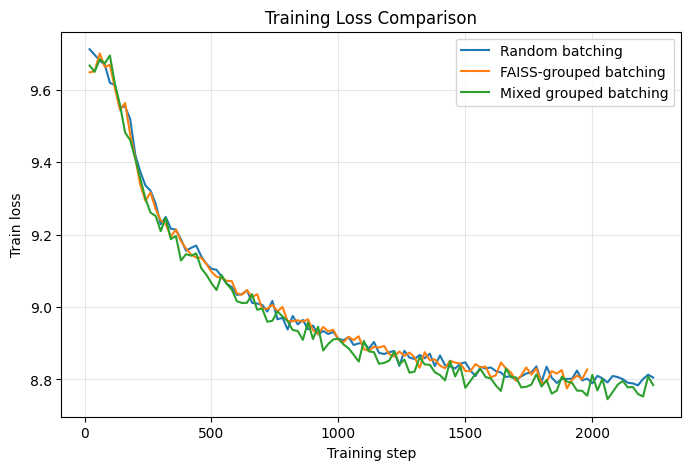

Saved: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard/plots/figure_1_loss_comparison.png


In [ ]:
# --- 11) Plot Figure-1: training loss comparison ---
plt.figure(figsize=(8, 5))

for run_name, run_info in runs.items():
    loss_df = run_info['loss_df']
    if loss_df.empty:
        continue

    label_map = {
        'baseline_random': 'Random batching',
        'grouped_faiss': 'FAISS-grouped batching',
        'grouped_mixed': 'Mixed grouped batching',
    }
    plt.plot(loss_df['step'], loss_df['loss'], label=label_map.get(run_name, run_name))

plt.xlabel('Training step')
plt.ylabel('Train loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
loss_cmp_path = f'{OUT_PLOTS}/figure_1_loss_comparison.png'
plt.savefig(loss_cmp_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', loss_cmp_path)

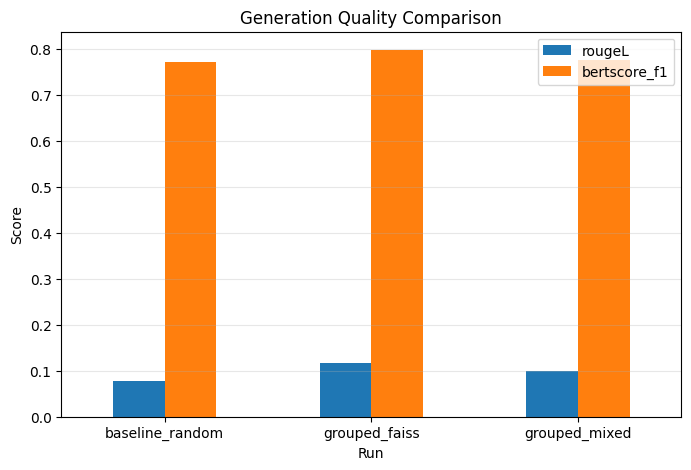

Saved: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard/plots/figure_2_generation_metrics.png


In [ ]:

# --- 12) Plot Figure-2: main generation metrics ---
plot_df = quality_df.set_index('run')[['rougeL', 'bertscore_f1']]
ax = plot_df.plot(kind='bar', figsize=(8, 5))
ax.set_title('Generation Quality Comparison')
ax.set_ylabel('Score')
ax.set_xlabel('Run')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=0)
quality_plot_path = f'{OUT_PLOTS}/figure_2_generation_metrics.png'
plt.savefig(quality_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', quality_plot_path)


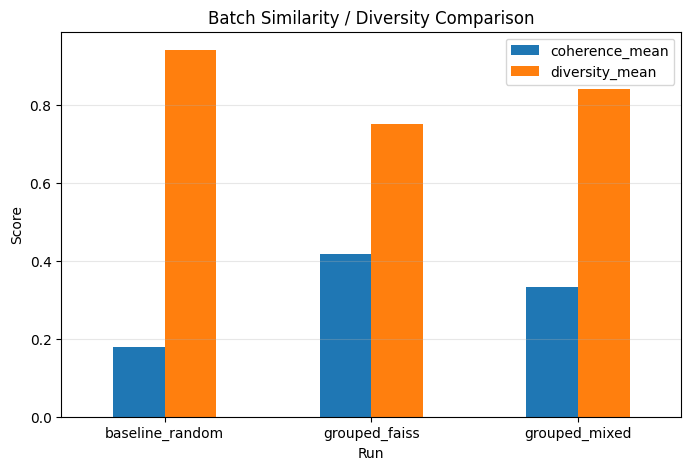

Saved: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard/plots/figure_3_batch_metrics.png


In [ ]:

# --- 13) Plot Figure-3: retrieval/grouping metrics ---
plot_df = batch_metrics_df.set_index('run')[['coherence_mean', 'diversity_mean']]
ax = plot_df.plot(kind='bar', figsize=(8, 5))
ax.set_title('Batch Similarity / Diversity Comparison')
ax.set_ylabel('Score')
ax.set_xlabel('Run')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=0)
retrieval_plot_path = f'{OUT_PLOTS}/figure_3_batch_metrics.png'
plt.savefig(retrieval_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', retrieval_plot_path)


In [ ]:

# --- 14) Write machine-readable evaluation manifest ---
eval_manifest = {
    'eval_exp_id': EVAL_EXP_ID,
    'baseline_exp_id': BASELINE_EXP_ID,
    'grouped_exp_id': GROUPED_EXP_ID,
    'dataset_name': DATASET_NAME,
    'base_model': BASE_MODEL_DIRNAME,
    'eval_samples': len(eval_ds),
    'paths': {
        'comparison_csv': comparison_csv,
        'quality_csv': f'{OUT_TABLES}/generation_quality_metrics.csv',
        'batch_metrics_csv': f'{OUT_TABLES}/batch_similarity_metrics.csv',
        'qual_examples_csv': examples_path,
        'loss_comparison_plot': loss_cmp_path,
        'generation_plot': quality_plot_path,
        'batch_metrics_plot': retrieval_plot_path,
    }
}

manifest_path = f'{OUT_LOGS}/eval_manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(eval_manifest, f, indent=2)

print('Wrote:', manifest_path)
print('Wrote:', comparison_csv)


Wrote: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard/logs/eval_manifest.json
Wrote: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard/tables/experiment_comparison_table.csv


In [ ]:
# --- 15) Rebuild clean experiment_logs.csv from current summaries + recomputed eval ---
def _summary_field(summary: Dict[str, Any], *keys, default=None):
    cur = summary
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

def _build_clean_experiment_log_rows():
    rows = []

    for run_name, run_info in runs.items():
        summary = run_info['summary']
        dyn = run_info['dyn']

        comp_row = comparison_df[comparison_df['run'] == run_name].iloc[0].to_dict()
        batch_row = batch_metrics_df[batch_metrics_df['run'] == run_name].iloc[0].to_dict()

        row = {
            'exp_id': run_info['exp_id'],
            'date_utc': _summary_field(summary, 'created_at_utc', default=None),
            'model': _summary_field(summary, 'base_model', default=BASE_MODEL_DIRNAME),
            'dataset': _summary_field(summary, 'dataset_name', default=DATASET_NAME),
            'method': _summary_field(summary, 'method', default=run_name),
            'batch_size': _summary_field(summary, 'hparams', 'per_device_batch', default=PER_DEVICE_BATCH),
            'grad_accum': _summary_field(summary, 'hparams', 'grad_accum', default=None),
            'lr': _summary_field(summary, 'hparams', 'lr', default=None),
            'epochs': _summary_field(summary, 'hparams', 'epochs', default=None),
            'seed': _summary_field(summary, 'seed', default=SEED),
            'created_at_utc': _summary_field(summary, 'created_at_utc', default=None),
            'dataset_name': _summary_field(summary, 'dataset_name', default=DATASET_NAME),
            'base_model': _summary_field(summary, 'base_model', default=BASE_MODEL_DIRNAME),
            'sampler_mode': _summary_field(summary, 'batching', 'sampler_mode', default=None),
            'grouped_fraction': _summary_field(summary, 'batching', 'grouped_fraction', default=None),
            'final_train_loss': dyn['final_train_loss'],
            'final_eval_loss': dyn['eval_loss'],
            'generalization_gap': dyn['generalization_gap'],
            'loss_variance': dyn['loss_variance'],
            'loss_std': dyn['loss_std'],
            'convergence_step_90pct': dyn['convergence_step_90pct'],
            'rouge1': comp_row['rouge1'],
            'rouge2': comp_row['rouge2'],
            'rougeL': comp_row['rougeL'],
            'rougeLsum': comp_row['rougeLsum'],
            'bertscore_precision': comp_row['bertscore_precision'],
            'bertscore_recall': comp_row['bertscore_recall'],
            'bertscore_f1': comp_row['bertscore_f1'],
            'coherence_mean': batch_row['coherence_mean'],
            'coherence_std': batch_row['coherence_std'],
            'diversity_mean': batch_row['diversity_mean'],
            'diversity_std': batch_row['diversity_std'],
        }

        rows.append(row)

    return pd.DataFrame(rows)

if REBUILD_EXPERIMENT_LOG_CSV:
    clean_log_df = _build_clean_experiment_log_rows()
    clean_log_df.to_csv(EXPERIMENT_LOG_CSV_PATH, index=False)
    print('Rebuilt clean experiment log at:', EXPERIMENT_LOG_CSV_PATH)
    clean_log_df

Rebuilt clean experiment log at: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/experiment_logs/experiment_logs.csv



## Recommended next step after this notebook

Run the exact same pipeline for multiple seeds:
- seed = 42
- seed = 43
- seed = 44

Then aggregate all runs into a **mean ± std** table. That will make your thesis claims much stronger and protect against the “this might just be randomness” objection.
